In [1]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score, f1_score
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score
import time
import shap
import optuna
import umap

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [3]:
annotated_control_vs_plasmid_EG = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid-vs-control-EG.csv")

In [4]:
annotated_control_vs_plasmid_EG.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,DO,-0.126512,non-hit,ENST00000357387.8,NM_152756.5,His1109Tyr,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,0.0685,NaN,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,DO,0.491844,non-hit,ENST00000369535.5,NM_002524.5,Leu171Phe,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,0.1149,NaN,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,DO,0.161287,non-hit,ENST00000674063.1,NM_006219.3,Thr930Ile,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,0.7209,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,DO,-0.429684,non-hit,ENST00000275493.7,NM_005228.5,Leu480Leu,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,DO,0.122982,non-hit,ENST00000621592.8,NM_002467.6,Asp2Asn,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,NaN,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN


In [5]:
annotated_control_vs_plasmid_EG['Cell_Line'].value_counts()

Cell_Line
A375    14043
HT29    14043
Name: count, dtype: int64

In [6]:
annotated_control_vs_plasmid_EG['Drug'].value_counts()

Drug
DO    28086
Name: count, dtype: int64

# Encode Labels

In [7]:
le = LabelEncoder()
annotated_control_vs_plasmid_EG['Hit_class_encoded'] = le.fit_transform(annotated_control_vs_plasmid_EG['Hit_class'])

In [8]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("Label mapping:", label_mapping)

Label mapping: {'negative': np.int64(0), 'non-hit': np.int64(1), 'positive': np.int64(2)}


# Handle Class Imbalance

In [10]:
#combined dataset
class_counts = annotated_control_vs_plasmid_EG['Hit_class_encoded'].value_counts()
class_proportions = annotated_control_vs_plasmid_EG['Hit_class_encoded'].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", (class_proportions*100).round(2))

Class counts:
 Hit_class_encoded
1    27065
0      810
2      211
Name: count, dtype: int64

Class percentage:
 Hit_class_encoded
1    96.36
0     2.88
2     0.75
Name: proportion, dtype: float64


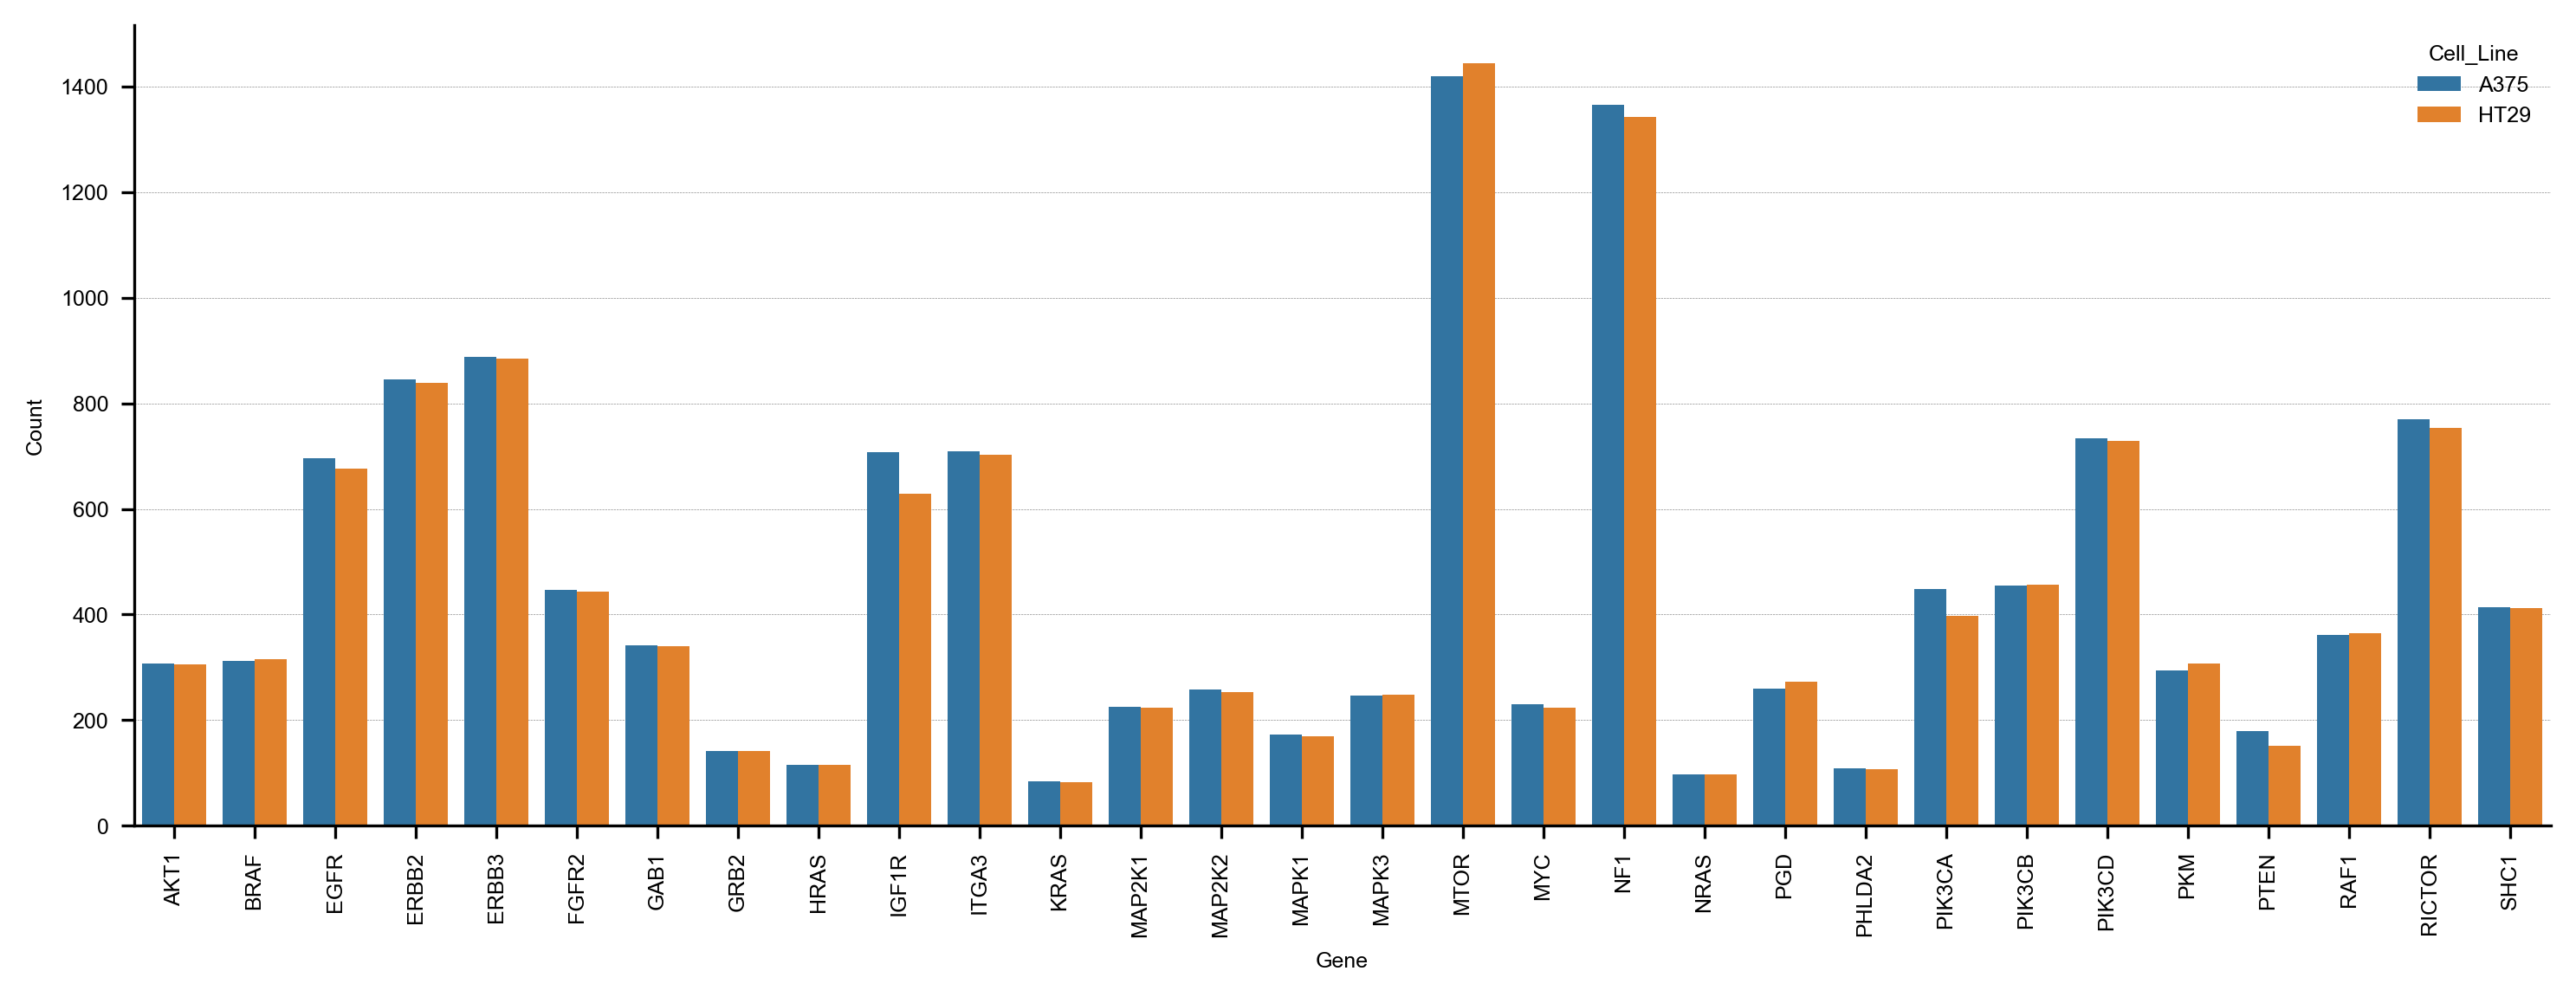

In [11]:
counts_before_DS = (
    annotated_control_vs_plasmid_EG
    .groupby(["Cell_Line", "Gene", "Hit_class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_before_DS = counts_before_DS[counts_before_DS["Hit_class"] == "non-hit"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_before_DS,
    x="Gene", y="Count", hue='Cell_Line', errorbar=None
)

plt.xticks(rotation=90)
plt.show()

### Stratified Downsampling

In [13]:
def stratified_downsampling(df, random_state=None):
    """
    Perform stratified downsampling of 'non-hit' class to match the size of the 'negative' class,
    stratified by (Cell_Line × Gene).
    
    Parameters
    ----------
    df : pd.DataFrame
        Original dataset with 'Hit_class', 'Cell_Line', and 'Gene'.
    random_state : int, optional
        Random seed for reproducibility of subsampling.

    Returns
    -------
    df_balanced : pd.DataFrame
        Balanced dataset containing all negatives, all positives, and downsampled non-hits.
    """
    #Split dataset by class
    df_negative = df[df['Hit_class'] == 'negative']
    df_non_hit = df[df['Hit_class'] == 'non-hit']
    df_positive = df[df['Hit_class'] == 'positive']

    #Target number of non-hit samples to match negative samples
    target_non_hit_count = len(df_negative)

    # Compute distribution of non-hits across Cell_Line × Gene
    non_hit_distribution = (
        df_non_hit
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    non_hit_distribution['Proportion'] = non_hit_distribution['Count'] / non_hit_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene
    non_hit_distribution['Target'] = np.floor(non_hit_distribution['Proportion'] * target_non_hit_count).astype(int)

    # Adjust target to ensure total matches target_non_hit_count - distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_non_hit_count - non_hit_distribution['Target'].sum()

    if difference > 0:
        fractional_parts = non_hit_distribution['Proportion'] * target_non_hit_count - non_hit_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        non_hit_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_non_hits = []
    for _, row in non_hit_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']
        
        subset = df_non_hit[(df_non_hit['Cell_Line'] == cell_line) & (df_non_hit['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case very small group
            downsampled_non_hits.append(subset.sample(n=n_sampled, random_state=random_state))
        
    df_non_hit_downsampled = pd.concat(downsampled_non_hits, ignore_index=True)

    # Combine downsampled non-hits with other classes
    df_balanced = pd.concat([df_negative, df_non_hit_downsampled, df_positive], ignore_index=True)

    return df_balanced

In [14]:
annotated_control_vs_plasmid_EG_balanced = stratified_downsampling(annotated_control_vs_plasmid_EG, random_state=1)

In [15]:
print("Final class counts:")
print(annotated_control_vs_plasmid_EG_balanced["Hit_class"].value_counts())

Final class counts:
Hit_class
negative    810
non-hit     810
positive    211
Name: count, dtype: int64


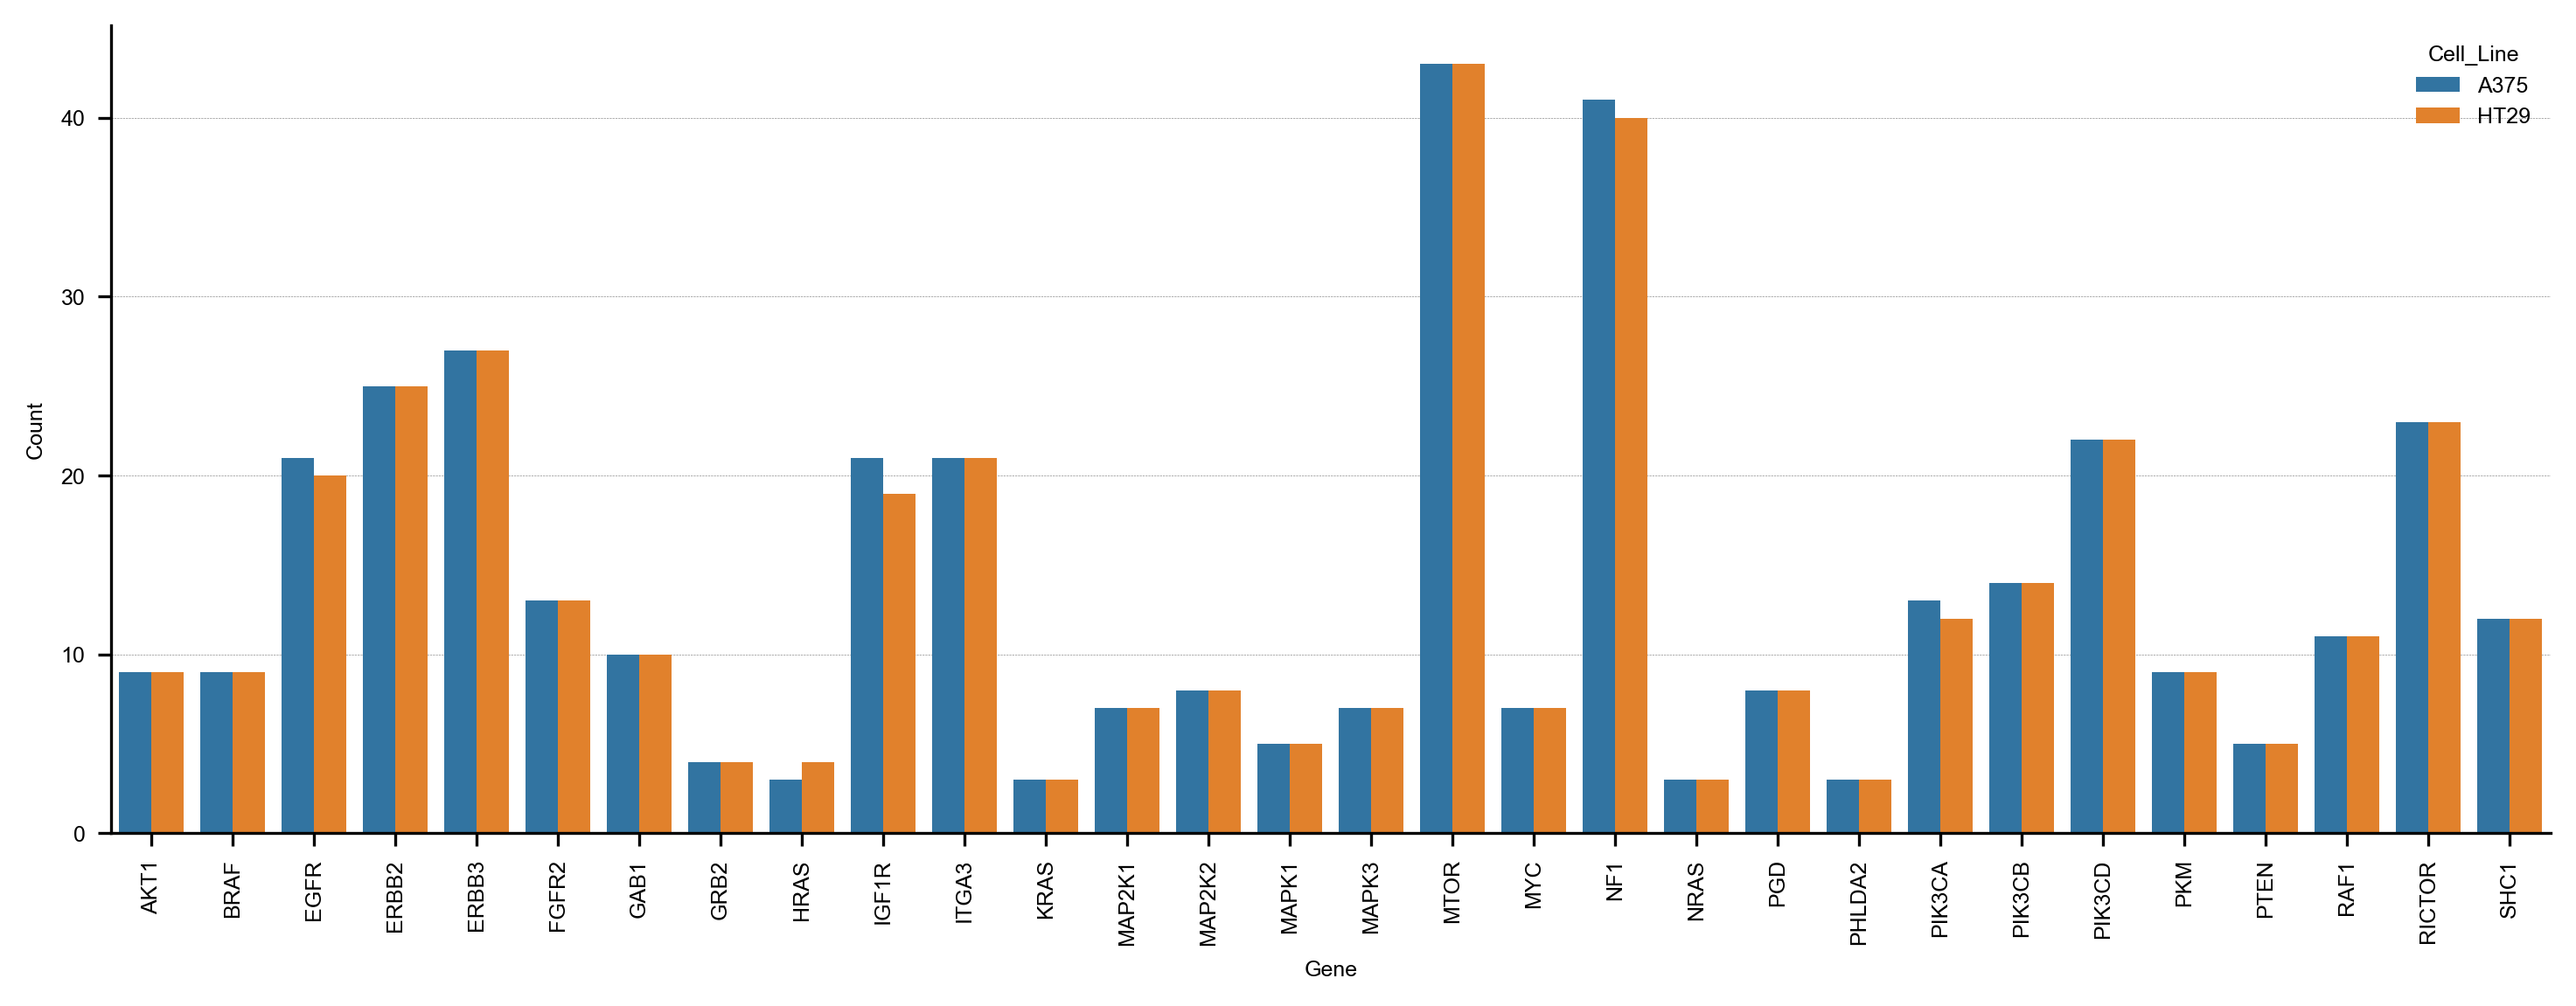

In [16]:
#Check distribution of non-hits after downsampling

counts_after_DS = (
    annotated_control_vs_plasmid_EG_balanced
    .groupby(["Cell_Line", "Gene", "Hit_class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_after_DS = counts_after_DS[counts_after_DS["Hit_class"] == "non-hit"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_after_DS,
    x="Gene", y="Count", hue="Cell_Line", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [17]:
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Cell_Line", "Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Cell_Line", "Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on=["Cell_Line", "Gene"], how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of per-group proportions (before vs after downsampling):", round(corr, 4))
print("\nProportion comparison (first 20 rows):")
print(prop_compare.head(20))

Correlation of per-group proportions (before vs after downsampling): 0.9995

Proportion comparison (first 20 rows):
   Cell_Line    Gene  Proportion_before_DS  Proportion_after_DS
0       A375    AKT1                0.0114               0.0111
1       A375    BRAF                0.0116               0.0111
2       A375    EGFR                0.0257               0.0259
3       A375   ERBB2                0.0312               0.0309
4       A375   ERBB3                0.0328               0.0333
5       A375   FGFR2                0.0165               0.0160
6       A375    GAB1                0.0126               0.0123
7       A375    GRB2                0.0052               0.0049
8       A375    HRAS                0.0042               0.0037
9       A375   IGF1R                0.0261               0.0259
10      A375   ITGA3                0.0262               0.0259
11      A375    KRAS                0.0031               0.0037
12      A375  MAP2K1                0.0083          

# Modeling

# Hyperparameter Tunning - Optuna Baysian Optimization

## XGBoost 